<a href="https://colab.research.google.com/github/roshan-beee/worldmonitor/blob/main/trans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Booting up the Digital Twin...
Generating all 5 different sounds...
Drawing all 5 graphs...


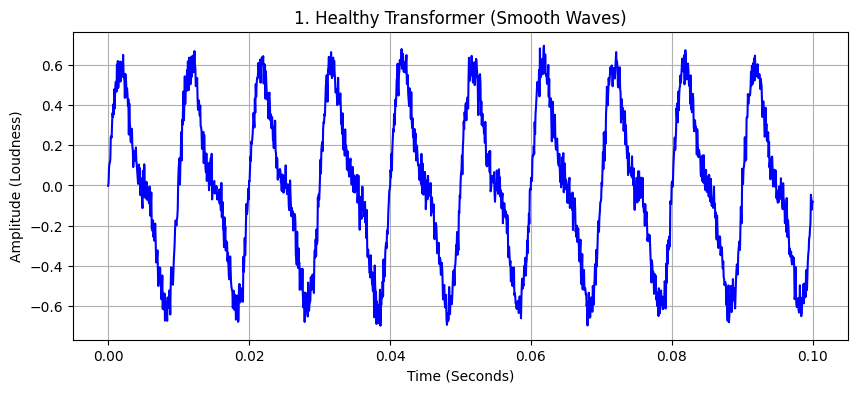

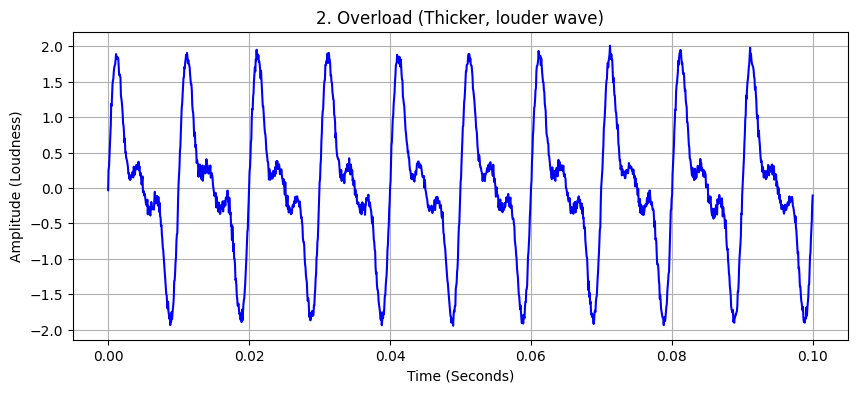

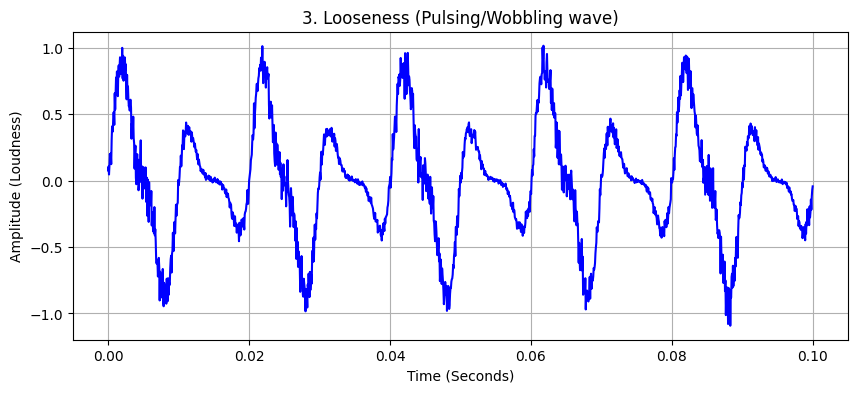

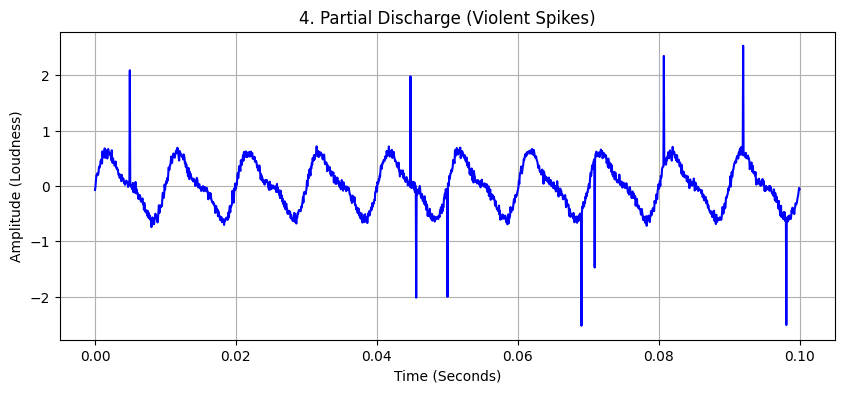

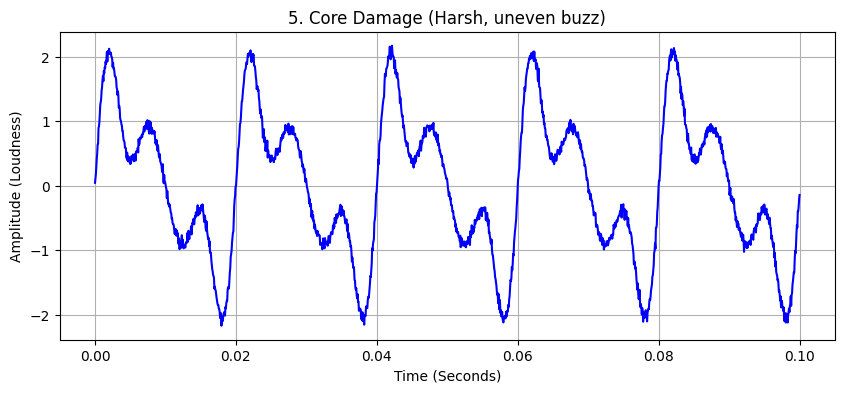

Saving the files...
✅ Success: Saved healthy_test.wav to your files!
✅ Success: Saved overload_test.wav to your files!
✅ Success: Saved looseness_test.wav to your files!
✅ Success: Saved discharge_test.wav to your files!
✅ Success: Saved core_damage_test.wav to your files!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# ==========================================
# 1. SAMRAT'S WORK: THE PHYSICS ENGINE
# ==========================================
class TransformerAcousticTwin:
    def __init__(self, duration=3.0, sample_rate=16000):
        self.duration = duration
        self.sample_rate = sample_rate
        # Create a time array (X-axis for our sound wave)
        self.t = np.linspace(0, self.duration, int(self.sample_rate * self.duration), endpoint=False)

    def generate_healthy(self):
        # A normal hum at 100Hz and 200Hz
        hum_100 = 0.5 * np.sin(2 * np.pi * 100 * self.t)
        hum_200 = 0.2 * np.sin(2 * np.pi * 200 * self.t)
        noise = np.random.normal(0, 0.05, len(self.t))
        return hum_100 + hum_200 + noise

    def inject_overload(self):
        # OVERLOAD: The machine is working too hard.
        # The hum gets louder and creates a new 300Hz ringing noise.
        hum_100 = 1.0 * np.sin(2 * np.pi * 100 * self.t)
        hum_200 = 0.8 * np.sin(2 * np.pi * 200 * self.t)
        hum_300 = 0.5 * np.sin(2 * np.pi * 300 * self.t)
        noise = np.random.normal(0, 0.05, len(self.t))
        return hum_100 + hum_200 + hum_300 + noise

    def inject_looseness(self):
        # LOOSENESS: Bolts are loose inside.
        # We take the healthy sound and make it pulse/vibrate (Amplitude Modulation).
        base_sound = self.generate_healthy()
        pulse = 1.0 + 0.8 * np.sin(2 * np.pi * 50 * self.t)
        return base_sound * pulse

    def inject_partial_discharge(self):
        # DISCHARGE: Electrical sparks are crackling inside.
        # We take the healthy sound and add random, sharp, loud spikes.
        base_sound = self.generate_healthy()
        spikes = np.random.choice([0, 2.0, -2.0], size=len(self.t), p=[0.995, 0.0025, 0.0025])
        return base_sound + spikes

    def inject_core_damage(self):
        # CORE DAMAGE: The iron core is physically broken/melted.
        # Creates a harsh, broken buzzing sound (strong odd frequencies).
        base_sound = self.generate_healthy()
        harsh_buzz_50 = 1.2 * np.sin(2 * np.pi * 50 * self.t)
        harsh_buzz_150 = 0.8 * np.sin(2 * np.pi * 150 * self.t)
        return base_sound + harsh_buzz_50 + harsh_buzz_150


# ==========================================
# 2. ROSHAN'S WORK: THE VISUALIZER
# ==========================================
def plot_sound(audio_array, title):
    # Slice the first 0.1 seconds so we can actually see the waves clearly
    short_audio = audio_array[:1600]
    time_x = np.linspace(0, 0.1, 1600)

    plt.figure(figsize=(10, 4))
    plt.plot(time_x, short_audio, color='blue')
    plt.title(title)
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Amplitude (Loudness)")
    plt.grid(True)
    plt.show()


# ==========================================
# 3. MOHIT'S WORK: THE SAVER
# ==========================================
def save_sound(audio_array, filename, sample_rate=16000):
    # This prevents the audio from being corrupted when saving
    max_val = np.max(np.abs(audio_array))
    if max_val > 0:
        audio_array = audio_array / max_val # Normalize

    # Save as a standard wav file format
    audio_array = np.float32(audio_array)
    wavfile.write(filename, sample_rate, audio_array)
    print(f"✅ Success: Saved {filename} to your files!")


# ==========================================
# 4. THE INTEGRATION TEST (Running it all together)
# ==========================================
print("Booting up the Digital Twin...")
twin = TransformerAcousticTwin()

print("Generating all 5 different sounds...")
healthy = twin.generate_healthy()
overload = twin.inject_overload()
loose = twin.inject_looseness()
discharge = twin.inject_partial_discharge()
core_damage = twin.inject_core_damage()

print("Drawing all 5 graphs...")
plot_sound(healthy, "1. Healthy Transformer (Smooth Waves)")
plot_sound(overload, "2. Overload (Thicker, louder wave)")
plot_sound(loose, "3. Looseness (Pulsing/Wobbling wave)")
plot_sound(discharge, "4. Partial Discharge (Violent Spikes)")
plot_sound(core_damage, "5. Core Damage (Harsh, uneven buzz)")

print("Saving the files...")
save_sound(healthy, "healthy_test.wav")
save_sound(overload, "overload_test.wav")
save_sound(loose, "looseness_test.wav")
save_sound(discharge, "discharge_test.wav")
save_sound(core_damage, "core_damage_test.wav")

In [3]:
from IPython.display import Audio, display

print("🎧 Listen to the Healthy Hum:")
display(Audio(healthy, rate=16000))

print("\n🎧 Listen to the Partial Discharge (Crackling/Sparks):")
display(Audio(discharge, rate=16000))

🎧 Listen to the Healthy Hum:



🎧 Listen to the Partial Discharge (Crackling/Sparks):


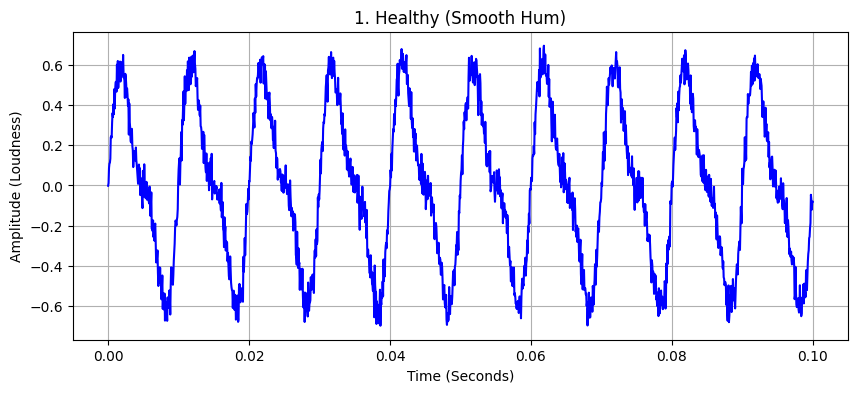

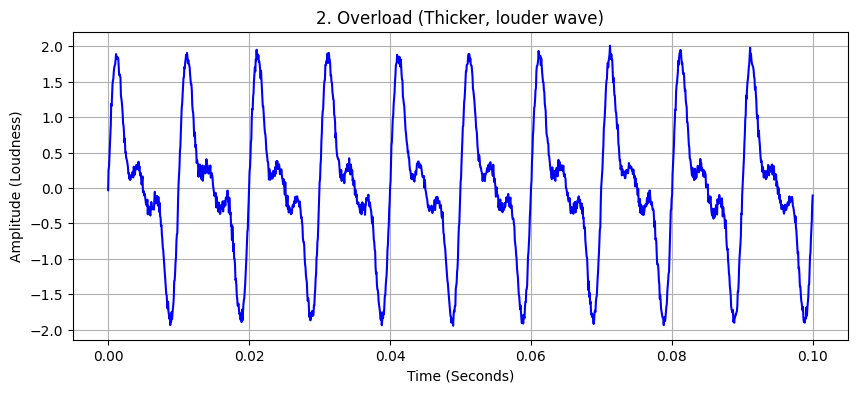

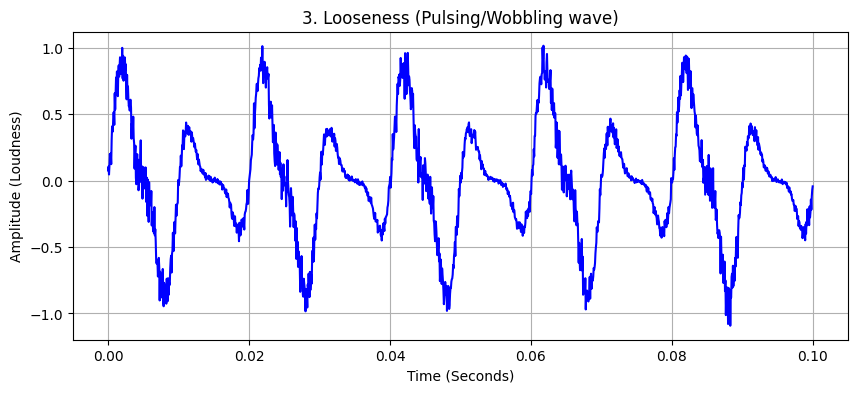

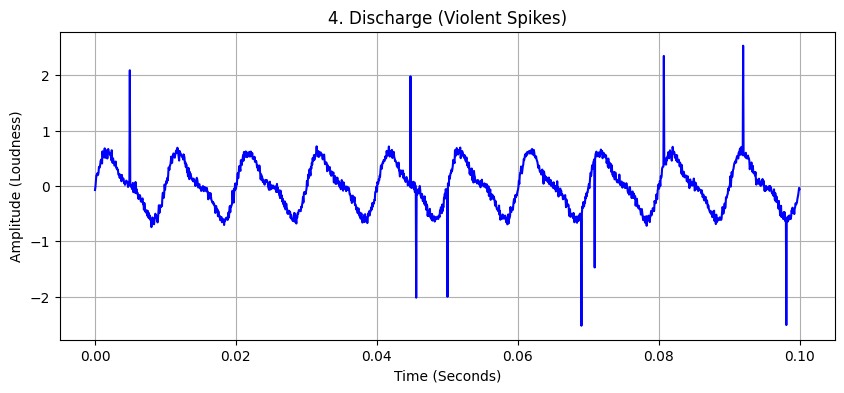

In [4]:
plot_sound(healthy, "1. Healthy (Smooth Hum)")
plot_sound(overload, "2. Overload (Thicker, louder wave)")
plot_sound(loose, "3. Looseness (Pulsing/Wobbling wave)")
plot_sound(discharge, "4. Discharge (Violent Spikes)")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import os
import numpy as np

# 1. Pointing to Mohit's Google Drive folders
BASE_DIR = "/content/drive/MyDrive/SIC_Capstone/Dataset"
folders = ['Healthy', 'Overload', 'Looseness', 'Discharge']

# Make sure the folders exist
for folder in folders:
    os.makedirs(f"{BASE_DIR}/{folder}", exist_ok=True)

# 2. Turn on the Factory Machine
print("🏭 Starting the Sound Factory... Please wait.")
twin = TransformerAcousticTwin()

# We want 150 files for each of the 4 categories (600 total)
total_files_per_fault = 150

for i in range(total_files_per_fault):

    # 1. Healthy
    healthy_audio = twin.generate_healthy()
    save_sound(healthy_audio, f"{BASE_DIR}/Healthy/healthy_{i}.wav")

    # 2. Overload
    overload_audio = twin.inject_overload()
    save_sound(overload_audio, f"{BASE_DIR}/Overload/overload_{i}.wav")

    # 3. Looseness
    loose_audio = twin.inject_looseness()
    save_sound(loose_audio, f"{BASE_DIR}/Looseness/looseness_{i}.wav")

    # 4. Discharge
    discharge_audio = twin.inject_partial_discharge()
    save_sound(discharge_audio, f"{BASE_DIR}/Discharge/discharge_{i}.wav")

    # Give us a progress update every 50 files
    if (i + 1) % 50 == 0:
        print(f"✅ Generated {i + 1} files for each category...")

print("🎉 MASS PRODUCTION COMPLETE! Check your Google Drive.")

🏭 Starting the Sound Factory... Please wait.
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Healthy/healthy_0.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Overload/overload_0.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Looseness/looseness_0.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Discharge/discharge_0.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Healthy/healthy_1.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Overload/overload_1.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Looseness/looseness_1.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Discharge/discharge_1.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Healthy/healthy_2.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/

In [7]:
import os

BASE_DIR = "/content/drive/MyDrive/SIC_Capstone/Dataset"
os.makedirs(f"{BASE_DIR}/Core_Damage", exist_ok=True)

print("🏭 Firing up the factory for Core Damage files...")
twin = TransformerAcousticTwin()

total_files = 150

for i in range(total_files):
    core_audio = twin.inject_core_damage()
    save_sound(core_audio, f"{BASE_DIR}/Core_Damage/core_damage_{i}.wav")

    if (i + 1) % 50 == 0:
        print(f"✅ Generated {i + 1} Core Damage files...")

print("🎉 ERROR FIXED! Core Damage folder is now full.")

🏭 Firing up the factory for Core Damage files...
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_0.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_1.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_2.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_3.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_4.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_5.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_6.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_7.wav to your files!
✅ Success: Saved /content/drive/MyDrive/SIC_Capstone/Dataset/Core_Damage/core_damage_8.wav to your file

In [8]:
import os
import pandas as pd

# 1. Point to your warehouse
BASE_DIR = "/content/drive/MyDrive/SIC_Capstone/Dataset"
folders = ['Healthy', 'Overload', 'Looseness', 'Discharge', 'Core_Damage']

# This empty list will hold our inventory data
inventory_list = []

print("📋 Inspector is walking through the folders...")

# 2. Walk through each folder
for label in folders:
    folder_path = f"{BASE_DIR}/{label}"

    # Get a list of every .wav file in this specific folder
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    # 3. Write each file down on our inventory list
    for file_name in files:
        # Hugging Face likes the path to look like "FolderName/FileName.wav"
        relative_path = f"{label}/{file_name}"
        inventory_list.append({"file_name": relative_path, "label": label})

# 4. Turn the list into a spreadsheet (CSV)
df = pd.DataFrame(inventory_list)
csv_path = f"{BASE_DIR}/metadata.csv"
df.to_csv(csv_path, index=False)

# 5. Print a success message and show a preview
print(f"✅ Map created successfully! The inspector found {len(df)} total audio files.")
print(f"📄 Saved the spreadsheet to: {csv_path}\n")
print("Here is a sneak peek of what the spreadsheet looks like:")
display(df.head())

📋 Inspector is walking through the folders...
✅ Map created successfully! The inspector found 750 total audio files.
📄 Saved the spreadsheet to: /content/drive/MyDrive/SIC_Capstone/Dataset/metadata.csv

Here is a sneak peek of what the spreadsheet looks like:


,file_name,label
0,Healthy/healthy_0.wav,Healthy
1,Healthy/healthy_1.wav,Healthy
2,Healthy/healthy_2.wav,Healthy
3,Healthy/healthy_3.wav,Healthy
4,Healthy/healthy_4.wav,Healthy


In [9]:
!pip install datasets transformers evaluate accelerate librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [10]:
from datasets import load_dataset, Audio

# 1. Point to the warehouse where the metadata.csv lives
BASE_DIR = "/content/drive/MyDrive/SIC_Capstone/Dataset"

print("🤖 Waking up the AI and handing it the Map...")

# 2. Use the "audiofolder" tool. This automatically reads metadata.csv and finds the audio!
dataset = load_dataset("audiofolder", data_dir=BASE_DIR)

# 3. CRITICAL PHYSICS STEP: Tell the AI to listen at exactly 16,000 Hz
# (If we don't do this, the AI might play the sound too fast or too slow!)
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print("\n✅ Success! The AI has loaded the warehouse into its memory.")
print("Here is what the AI sees in its brain right now:")
print(dataset)

🤖 Waking up the AI and handing it the Map...


Resolving data files:   0%|          | 0/751 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]


✅ Success! The AI has loaded the warehouse into its memory.
Here is what the AI sees in its brain right now:
DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 750
    })
})


In [11]:
print("🔀 Shuffling files and locking away the Final Exam...")

# This takes our single 'train' pile and splits it 80% / 20%
# The 'seed=42' just ensures it splits the exact same way if we have to restart
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print("\n✅ Splitting complete!")
print("Here is the new map in the AI's brain:")
print(dataset)

🔀 Shuffling files and locking away the Final Exam...

✅ Splitting complete!
Here is the new map in the AI's brain:
DatasetDict({
    train: Dataset({
        features: ['audio', 'label'],
        num_rows: 600
    })
    test: Dataset({
        features: ['audio', 'label'],
        num_rows: 150
    })
})


In [12]:
from transformers import AutoFeatureExtractor

# 1. Bring in the official AST Translator from Hugging Face
print("🎧 Downloading the Audio Translator...")
model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"
feature_extractor = AutoFeatureExtractor.from_pretrained(model_id)

# 2. Create the translation rules
def translate_audio(batch):
    # Grab the raw audio numbers
    audio = batch["audio"]
    # Translate them into the spectrogram format the AI understands
    inputs = feature_extractor(audio["array"], sampling_rate=feature_extractor.sampling_rate, max_length=1024, truncation=True)
    # Save the translated data into a new column called 'input_values'
    batch["input_values"] = inputs.get("input_values")[0]
    return batch

print("🔄 Translating all 750 files... This will take a minute or two!")

# 3. Apply the translation to both the train and test piles
# We remove the old 'audio' column because the AI doesn't need the raw sound anymore
encoded_dataset = dataset.map(translate_audio, remove_columns=["audio"])

print("\n✅ Translation complete! The data is officially ready for the AI Brain.")
print("Here is the updated format:")
print(encoded_dataset)

🎧 Downloading the Audio Translator...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

🔄 Translating all 750 files... This will take a minute or two!


Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Map:   0%|          | 0/150 [00:00<?, ? examples/s]


✅ Translation complete! The data is officially ready for the AI Brain.
Here is the updated format:
DatasetDict({
    train: Dataset({
        features: ['label', 'input_values'],
        num_rows: 600
    })
    test: Dataset({
        features: ['label', 'input_values'],
        num_rows: 150
    })
})


In [13]:
from transformers import AutoModelForAudioClassification

print("⚙️ Converting text labels into official AI categories...")
# THE FIX: This line forces the text strings to become official ClassLabels
encoded_dataset = encoded_dataset.class_encode_column("label")

# 1. Create the Number-to-Word Dictionary
labels = encoded_dataset["train"].features["label"].names
label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

print("🏷️ The AI's Answer Key:")
print(id2label)

# 2. Download the AI Brain
print("\n🧠 Downloading the AST Model Brain...")
model_id = "MIT/ast-finetuned-audioset-10-10-0.4593"

# We load the model and tell it we only have 5 labels now.
# CRITICAL: ignore_mismatched_sizes=True tells the model it is okay to
# forget the original 527 sounds and replace them with our 5 sounds!
model = AutoModelForAudioClassification.from_pretrained(
    model_id,
    num_labels=len(labels),
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True
)

print("\n✅ Brain surgery complete! The AI is ready to learn your 5 sounds.")

⚙️ Converting text labels into official AI categories...


Casting to class labels:   0%|          | 0/600 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/150 [00:00<?, ? examples/s]

🏷️ The AI's Answer Key:
{'0': 'Core_Damage', '1': 'Discharge', '2': 'Healthy', '3': 'Looseness', '4': 'Overload'}

🧠 Downloading the AST Model Brain...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([5, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([5])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



✅ Brain surgery complete! The AI is ready to learn your 5 sounds.


In [14]:
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

# 1. THE GRADING RUBRIC
print("📝 Creating the Accuracy Grading Rubric...")
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    # The AI gives us probabilities. We pick the highest probability as its "Final Answer"
    predictions = np.argmax(eval_pred.predictions, axis=1)
    # We compare its answers against the real answers (labels)
    return accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)

# 2. THE CLASSROOM RULES
print("🏫 Setting up the Classroom rules...")
training_args = TrainingArguments(
    output_dir="./transformer_ai_model", # Where to save the AI after it studies
    eval_strategy="epoch",               # FIXED: The new Hugging Face rule name!
    save_strategy="epoch",               # Save a backup copy after every read-through
    learning_rate=3e-5,                  # How fast the AI updates its brain
    per_device_train_batch_size=8,       # Study 8 audio files at a time
    per_device_eval_batch_size=8,        # Take the test 8 files at a time
    num_train_epochs=5,                  # Read the entire 600-file textbook exactly 5 times
    logging_steps=10,                    # Give us an update every 10 steps
    load_best_model_at_end=True,         # Keep the smartest version of the brain
    metric_for_best_model="accuracy",    # "Smartest" means the highest accuracy score
    push_to_hub=False,
)

# 3. PUTTING THE STUDENT IN THE CLASSROOM
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"], # The Study Pile (600 files)
    eval_dataset=encoded_dataset["test"],   # The Test Vault (150 files)
    compute_metrics=compute_metrics,        # The Grading Rubric
)

print("✅ Classroom is built! The AI is sitting at its desk, ready to start studying.")

📝 Creating the Accuracy Grading Rubric...


🏫 Setting up the Classroom rules...
✅ Classroom is built! The AI is sitting at its desk, ready to start studying.


In [ ]:
print("🚀 Initiating AI Training Sequence...")
print("The AI is now reading the 600 files and testing itself. This might take 5 to 10 minutes!")

# The magic command that starts the learning process
trainer.train()

print("🎉 TRAINING COMPLETE! Your AI has officially learned the physics of transformers.")

🚀 Initiating AI Training Sequence...
The AI is now reading the 600 files and testing itself. This might take 5 to 10 minutes!


Epoch,Training Loss,Validation Loss,Accuracy
1,0.000050,0.000043,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Day 3

In [ ]:
# 1. Re-connect to your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Re-install the Hugging Face AI tools
!pip install datasets transformers evaluate accelerate librosa

In [ ]:
import os
import evaluate
import numpy as np
from datasets import load_dataset, Audio
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, TrainingArguments, Trainer

print("1. Loading the files...")
dataset = load_dataset("audiofolder", data_dir="/content/drive/MyDrive/SIC_Capstone/Dataset")
dataset = dataset.cast_column("audio", Audio(sampling_rate=16000))

print("2. Splitting into Study (80%) and Test (20%) piles...")
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)

print("3. Translating Audio to Spectrograms...")
feature_extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

def translate_audio(batch):
    inputs = feature_extractor(batch["audio"]["array"], sampling_rate=feature_extractor.sampling_rate, max_length=1024, truncation=True)
    batch["input_values"] = inputs.get("input_values")[0]
    return batch

encoded_dataset = dataset.map(translate_audio, remove_columns=["audio"])
encoded_dataset = encoded_dataset.class_encode_column("label")

print("4. Doing Brain Surgery on the Model...")
labels = encoded_dataset["train"].features["label"].names
label2id = {label: str(i) for i, label in enumerate(labels)}
id2label = {str(i): label for i, label in enumerate(labels)}

model = AutoModelForAudioClassification.from_pretrained(
    "MIT/ast-finetuned-audioset-10-10-0.4593",
    num_labels=len(labels), label2id=label2id, id2label=id2label,
    ignore_mismatched_sizes=True
)

print("5. Building the Classroom...")
accuracy_metric = evaluate.load("accuracy")
def compute_metrics(eval_pred):
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return accuracy_metric.compute(predictions=predictions, references=eval_pred.label_ids)

training_args = TrainingArguments(
    output_dir="./transformer_ai_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_dataset["train"],
    eval_dataset=encoded_dataset["test"],
    processing_class=feature_extractor,
    compute_metrics=compute_metrics,
)

print("✅ Setup Complete! Ready for takeoff.")

In [ ]:
print("🚀 Initiating High-Speed GPU Training Sequence...")
trainer.train()

In [ ]:
print("🔒 Securing AI Asset to Google Drive Vault...")

# Define the safe path in your Drive
save_directory = "/content/drive/MyDrive/SIC_Capstone/Trained_AI_Brain"

# Save the Brain (Model) and the Ears (Feature Extractor)
model.save_pretrained(save_directory)
feature_extractor.save_pretrained(save_directory)

print(f"✅ SUCCESS! The AI Brain is permanently secured at: {save_directory}")

In [ ]:
import numpy as np
from scipy.io import wavfile
import os

print("⏱️ Initializing The Time Machine Generator...")

# 1. Create a new folder specifically for the pitch demonstration
demo_folder = "/content/drive/MyDrive/SIC_Capstone/Pitch_Demo"
os.makedirs(demo_folder, exist_ok=True)

# 2. Setup the 2-minute timeline
sample_rate = 16000
duration_seconds = 120
t = np.linspace(0, duration_seconds, int(sample_rate * duration_seconds), endpoint=False)

print("🔊 Synthesizing 2-month degradation into 2 minutes...")

# 3. Base Hum (Healthy Transformer)
base_hum = 0.8 * np.sin(2 * np.pi * 100 * t) + 0.4 * np.sin(2 * np.pi * 200 * t)

# 4. The Degradation Curve (starts slow, gets rapidly worse at the end)
degradation_curve = (t / duration_seconds) ** 2

# 5. The Fault (Mechanical Looseness & Rattle getting louder over time)
looseness_vibration = 1.5 * np.sin(2 * np.pi * 50 * t) * degradation_curve
metallic_rattle = np.random.normal(0, 0.5, len(t)) * degradation_curve

# Combine them all
final_audio = base_hum + looseness_vibration + metallic_rattle

# Normalize to prevent audio clipping/static
final_audio = final_audio / np.max(np.abs(final_audio))

# Convert to standard 16-bit format
audio_int16 = np.int16(final_audio * 32767)

# Save the file
save_path = os.path.join(demo_folder, "2_Min_Looseness_Degradation.wav")
wavfile.write(save_path, sample_rate, audio_int16)

print(f"✅ SUCCESS! Time-Lapse Audio saved to: {save_path}")